In [1]:
from data_process import prepare
import os
import tensorflow as tf
import tensorflow.keras as keras
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

2025-01-11 15:50:06.394625: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered


In [18]:
print(tf.__version__)

2.17.0


In [19]:
# Load the best model
model_path = os.getcwd() + '/saved_models/best_model.keras'
best_model = keras.models.load_model(model_path)
best_model.summary()

Model: "classifier_to_explain"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, 256, 256, 1)    │       131,073 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,031,692 (49.71 MB)

 Trainable params: 4,300,131 (16.40 MB)

 Non-trainable params: 131,297 (512.88 KB)

 Optimizer params: 8,600,264 (32.81 MB)

In [63]:
labels = np.load('./dataset/labels.npy')
images = np.load('./dataset/images.npy', mmap_mode='r')
masks = np.load('./dataset/masks.npy', mmap_mode='r')
patient_ids = np.load('./dataset/patient_ids.npy').flatten()
file_paths = np.load('./dataset/file_paths.npy')
for i, label in enumerate(labels):
    print(i, label)
classes  = ['Meningioma Tumor', 'Glioma Tumor', 'Pituitary Tumor']

0 2
1 3
2 2
3 3
4 3
5 1
6 1
7 2
8 1
9 1
10 2
11 1
12 2
13 2
14 3
15 3
16 1
17 2
18 3
19 1
20 2
21 2
22 3
23 3
24 3
25 1
26 2
27 2
28 2
29 3
30 2
31 1
32 2
33 1
34 2
35 2
36 1
37 1
38 3
39 1
40 1
41 2
42 2
43 1
44 2
45 2
46 3
47 3
48 1
49 3
50 3
51 1
52 2
53 1
54 2
55 3
56 2
57 2
58 2
59 3
60 2
61 1
62 2
63 3
64 1
65 3
66 2
67 2
68 3
69 2
70 3
71 2
72 1
73 3
74 3
75 2
76 2
77 3
78 3
79 3
80 3
81 2
82 3
83 2
84 1
85 2
86 2
87 3
88 2
89 2
90 2
91 2
92 3
93 2
94 1
95 2
96 1
97 1
98 2
99 2
100 3
101 2
102 2
103 3
104 2
105 1
106 1
107 3
108 2
109 2
110 2
111 3
112 2
113 2
114 2
115 2
116 2
117 1
118 1
119 2
120 1
121 3
122 3
123 1
124 1
125 2
126 1
127 2
128 1
129 3
130 2
131 1
132 3
133 1
134 3
135 1
136 1
137 3
138 3
139 2
140 2
141 2
142 2
143 3
144 3
145 2
146 2
147 3
148 1
149 3
150 2
151 2
152 2
153 1
154 2
155 2
156 2
157 2
158 1
159 3
160 2
161 3
162 3
163 2
164 2
165 2
166 1
167 2
168 2
169 3
170 3
171 1
172 1
173 2
174 2
175 3
176 2
177 1
178 2
179 2
180 1
181 3
182 3
183 2
184 1


In [64]:
ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
ds = prepare(ds, shuffle=False, augment=False)

In [22]:
def get_example_by_idx(ds, i):
    """
    Return the example at index i in the dataset ds
    """
    ds_iterator = iter(ds)
    X, y = next(ds_iterator)
    while i >= X.shape[0]:
        try:
            i -= X.shape[0]
            X, y = next(ds_iterator)
        except StopIteration:
            return None
    return tf.cast(X[i], tf.float32) , y[i]
        

# Feature attribution for explaining classifier predictions

## Saliency maps

In [23]:
def compute_saliency_map(model, ds, idx):
    """
    Return a 2D array representing gradient magnitude of each input feature of x
    w.r.t to the highest class activation for x.
    """
    image, target_onehot = get_example_by_idx(ds,idx)
    label = classes[np.argmax(target_onehot)]
    with tf.GradientTape() as tape:
        tape.watch(image)
        # expand dims to create a "batch" with a single example
        class_activations = best_model(tf.expand_dims(image, 0))
        class_activations = tf.squeeze(class_activations)
        largest_activation = class_activations[np.argmax(class_activations)]
    
    grad_x = tape.gradient(largest_activation, image).numpy()
    # bg_ind = (image.numpy() > (10 ** 2)).astype(int)
    grad_mag_x = np.abs(grad_x) # * bg_ind
    
    print(np.min(grad_mag_x), np.max(grad_mag_x), np.median(grad_mag_x))
    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(image, cmap='gray')
    mask = np.ma.masked_where(masks[idx] == False, masks[idx])
    ax[0].imshow(mask, alpha=0.3, cmap='Set1')
    ax[0].set_title(f'Ground truth : {label}')
    ax[1].imshow(grad_mag_x, vmin=np.min(grad_mag_x), vmax=np.percentile(grad_mag_x, 99) , cmap='gray')
    ax[1].set_title('Saliency Map')
    

0.0 28.13112 4.8755977e-09


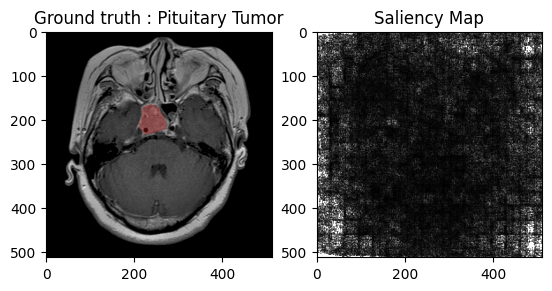

In [24]:
compute_saliency_map(best_model, ds, 50)

## Grad-CAM

In [94]:
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
from tf_keras_vis.utils.scores import CategoricalScore
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K

def compute_gradcam(model, dataset, idx):
    """
    Compute Grad-CAM visualization of a prediction for a single data point.
    """

    image, target_onehot  = get_example_by_idx(ds,idx)
    label = classes[np.argmax(target_onehot)]
    
    last_conv_layer_name = "conv2d_3"
    last_conv_layer = model.get_layer(last_conv_layer_name)

    final_dense_layer_name = "dense_1"
    final_dense_layer = model.get_layer(final_dense_layer_name)
    final_dense_layer.activation = None

    feature_extractor = keras.models.Model(
        inputs=[model.inputs],
        outputs=[last_conv_layer.output]
    )

    with tf.GradientTape() as tape:

        input_tensor = tf.expand_dims(image, 0)
        conv_outputs = feature_extractor(input_tensor)
        
        tape.watch(conv_outputs)
        inputs = tf.keras.Input(shape=conv_outputs.shape[1:])
        
        x = inputs
        for layer in model.layers[model.layers.index(last_conv_layer) + 1:]:
            x = layer(x)
        grad_model = tf.keras.Model(inputs, x)
        predictions = grad_model(conv_outputs)
        
        predictions = predictions[0]        
        loss = predictions[tf.argmax(predictions)]

    grads = tape.gradient(loss, conv_outputs)

    grads = tf.squeeze(grads)
    conv_outputs = tf.squeeze(conv_outputs)
    
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
    
    cam = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    image = image.numpy().squeeze()
    (w, h) = (image.shape[1], image.shape[0])
    heatmap = cv2.resize(cam.numpy(), (w, h))
    
    
    eps = 1e-8
    
    heatmap = (heatmap - np.min(heatmap)) / (heatmap.max() - heatmap.min() + eps)
    heatmap = (heatmap * 255).astype("uint8")
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_VIRIDIS)

    # Visualize the heatmap in on the input data point
    image = (image - np.min(image)) / (image.max() - image.min() + eps)
    image = (image * 255).astype("uint8")
    image = cv2.cvtColor(image,cv2.COLOR_GRAY2RGB)
    
    output = image * 0.5 + heatmap * 0.5
    output = (output - output.min()) / (output.max() - output.min() + eps)

    fig, ax = plt.subplots(1, 2)
    ax[0].imshow(image)
    mask = np.ma.masked_where(masks[idx] == False, masks[idx])
    ax[0].imshow(mask, alpha=0.3, cmap='Set1')
    ax[0].set_title(f'Ground Truth: {label}')
    ax[1].imshow(output)
    ax[1].set_title('Grad-CAM Heatmap')
    fig.savefig(f'figures/gradcam_{idx}.png')
    


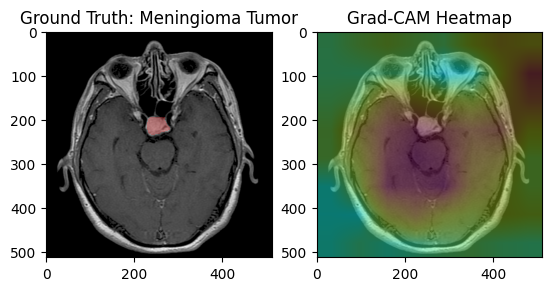

In [95]:
compute_gradcam(best_model, ds, 1048)

### Data Point IDs for Visualization Examples

Meningioma:
- coronal plane: 5, 431, 971
- sagittal plane: 180, 1551, 436
- axial plane: 9, 1552, 1048
Glioma Tumor:
- coronal plane: 71
- sagittal plane: 62
- axial plane: 56
Pituitary Tumor:
- coronal plane: 14
- sagittal plane: 92
- axial plane: 1537

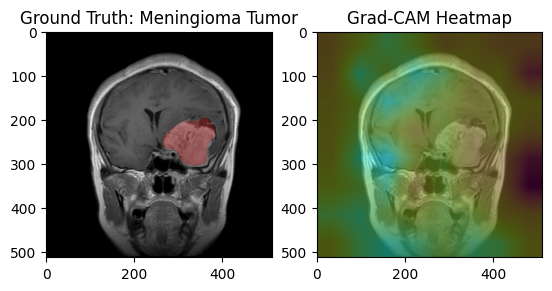

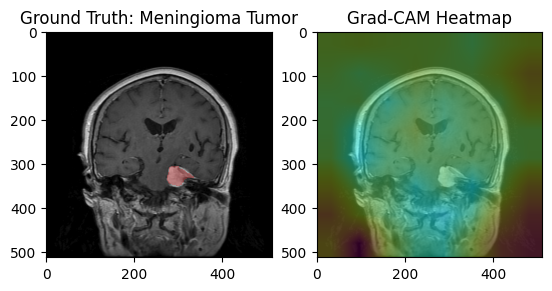

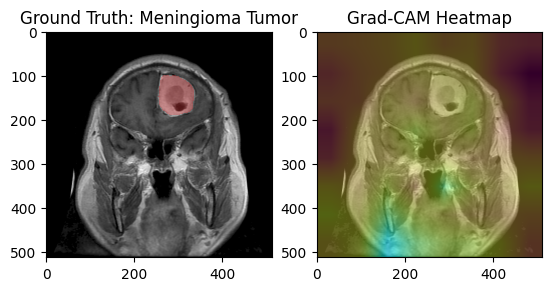

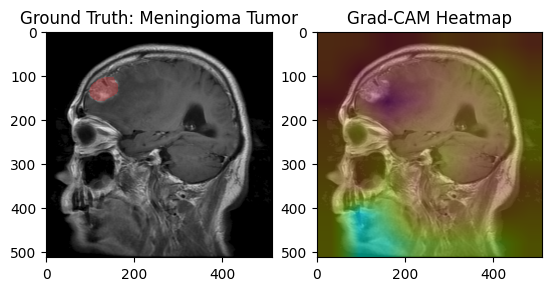

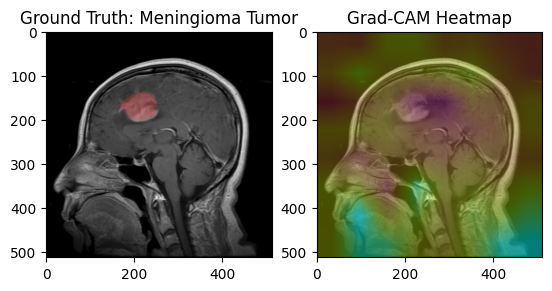

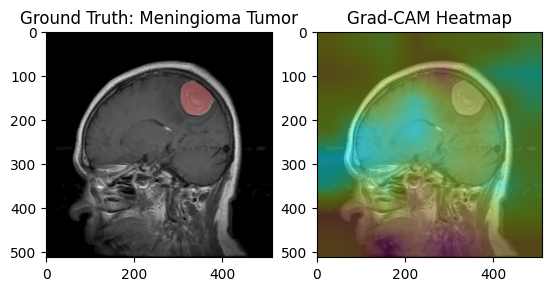

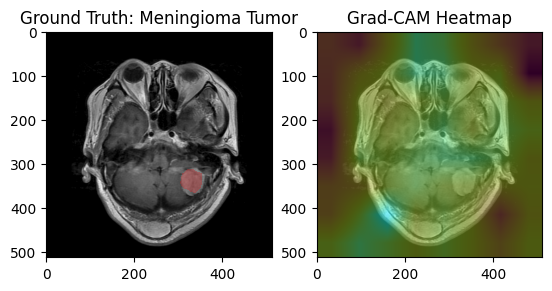

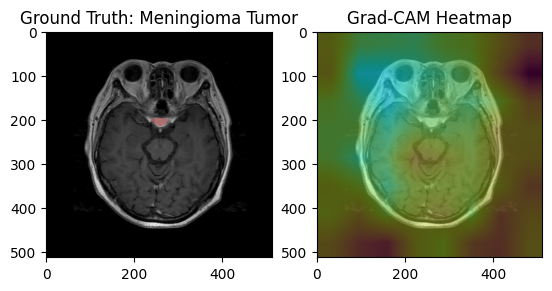

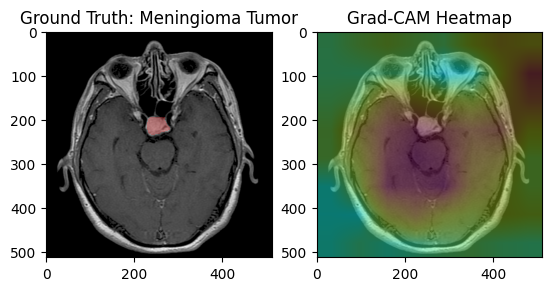

In [96]:
idxs = [5, 431, 971, 180, 1551, 436, 9, 1552, 1048]

for idx in idxs:
    compute_gradcam(best_model, ds, idx)